# HNL reach to high mass with DarkNews cross sections

Extends `hnl_dipole_sensitivity.ipynb` to **higher HNL masses** by replacing the
analytic leading-log upscattering estimate with **DarkNews** cross sections
(coherent + nucleon-elastic; `DarkNewsPortal` in `mint/hnl_tools.py`).

Why this matters at high mass: producing a heavy $N$ needs momentum transfer
$Q\gtrsim m_N^2/2E_\nu$. As $m_N$ grows this **breaks nuclear coherence** (the form
factor cuts off at $Q\sim 1/R_A\sim$ tens of MeV), so the coherent rate collapses and
the **incoherent (nucleon-elastic)** channel takes over. DarkNews computes both with
real form factors and the full $m_N$ dependence; the analytic $\propto Z^2\ln(\cdot)$
estimate has no such turn-off and badly overshoots at high mass.

Only production comes from DarkNews (coherent + `p-el` + `n-el`); decays stay analytic
($N\to\nu\gamma$ for the dipole). The cross section scales exactly as coupling$^2$, so
it is tabulated once per mass and rescaled.

In [6]:
import numpy as np
import matplotlib.pyplot as plt

from mint import lattice_tools as lt, beam_optics as bopt, const
from mint import detector_tools as dt
from mint import hnl_tools as hnl
from mint.MuC import MuDecaySimulator

import vector
np.random.seed(1)


## 1. Forward flux at 5 km

In [7]:
ring_df = lt.get_lattice_dataframe_from_tfs("beam-optics/twiss_ir1ccma_hybrid_v06.outx")
ring = lt.Lattice(**bopt.create_smoothed_lattice(
    ring_df, emittance_RMS=25e-6/(5e3/0.105), n_elements=120000,
    rotated=True, if_sublattice=False, midpoint=True))
ring.Nmu_per_bunch, ring.finj, ring.bunch_multiplicity, ring.duty_factor = 2e12, 5.0, 1.0, 1/np.pi

sim = MuDecaySimulator(muon_polarization=0.0, lattice=ring, nuflavor="numubar",
                       n_evals=3e5, beam_dynamics=True)
sim.decay_muons(); sim.place_muons_on_lattice(lattice=ring, direction="clockwise")
bunches_per_year = ring.finj * ring.bunch_multiplicity * ring.duty_factor * const.s_in_year

DIST, DET_R = 5e5, 100.0
det_vec = vector.array({"x":[0.0],"y":[0.0],"z":[DIST]})
dotprod = (det_vec - sim.pos).dot(sim.pnu.to_3D().unit())
t = (DIST - sim.pos["z"]) / sim.pnu["pz"]
r_hit = np.sqrt((sim.pos["x"]+t*sim.pnu["px"])**2 + (sim.pos["y"]+t*sim.pnu["py"])**2)
hit = (dotprod > 0) & (sim.pnu["E"] > 0) & (r_hit < DET_R)
E_nu = sim.pnu["E"][hit]
w_nu = sim.weights.flatten()[hit] * bunches_per_year
print(f"flux through the face: {w_nu.sum():.2e} nu/yr;  <E>={np.average(E_nu, weights=w_nu)/1e3:.2f} TeV")


Setting additional dispersion_Dx to <scipy.interpolate._interpolate.interp1d object at 0x16b28f070>
Setting additional dispersion_Dpx to <scipy.interpolate._interpolate.interp1d object at 0x16b28ee40>
Setting additional betx to <scipy.interpolate._interpolate.interp1d object at 0x16b28ed50>
Setting additional bety to <scipy.interpolate._interpolate.interp1d object at 0x16b28ceb0>
Setting additional gamx to <scipy.interpolate._interpolate.interp1d object at 0x16b28d540>
Setting additional gamy to <scipy.interpolate._interpolate.interp1d object at 0x16b28e6c0>
Setting additional alfx to <scipy.interpolate._interpolate.interp1d object at 0x16b28f980>
Setting additional alfy to <scipy.interpolate._interpolate.interp1d object at 0x16b28c410>
Setting additional cov_x_xp to <scipy.interpolate._interpolate.interp1d object at 0x16b28cd20>
Setting additional cov_y_yp to <scipy.interpolate._interpolate.interp1d object at 0x16b28fb60>
Setting additional sigma_xp to <scipy.interpolate._interpolate.

## 2. DarkNews cross section: coherent vs incoherent, and where coherence dies

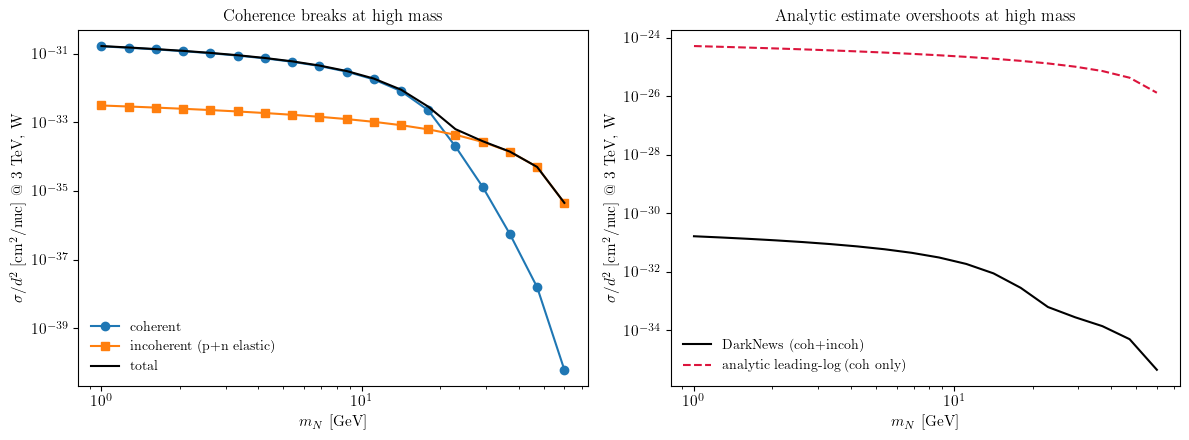

In [8]:
Egrid = np.geomspace(50, 5e3, 12)
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

# (a) coherent vs incoherent vs mass, dipole, tungsten, at E = 3 TeV
E1 = np.array([3000.])
masses = np.geomspace(1.0, 60.0, 18)
coh, inc = [], []
for m in masses:
    coh.append(hnl.darknews_upscattering_xsec(E1, m, "dipole", "W184", regimes=("coherent",))[0])
    inc.append(hnl.darknews_upscattering_xsec(E1, m, "dipole", "W184", regimes=("p-el","n-el"))[0])
coh, inc = np.array(coh), np.array(inc)
ax[0].plot(masses, coh, "o-", label="coherent", color="tab:blue")
ax[0].plot(masses, inc, "s-", label="incoherent (p+n elastic)", color="tab:orange")
ax[0].plot(masses, coh+inc, "-", color="black", label="total")
ax[0].set_xscale("log"); ax[0].set_yscale("log")
ax[0].set_xlabel(r"$m_N$ [GeV]"); ax[0].set_ylabel(r"$\sigma/d^2$ [cm$^2$/nuc] @ 3 TeV, W")
ax[0].legend(frameon=False); ax[0].set_title("Coherence breaks at high mass")

# (b) DarkNews total vs the analytic leading-log estimate (dipole)
dn_tot = np.array([hnl.darknews_upscattering_xsec(E1, m, "dipole", "W184")[0] for m in masses])
an = np.array([hnl.dipole_coherent_xsec(E1, m, 1.0, dt.W.Z, dt.W.A)[0]
               for m in masses])  # analytic at d = 1 GeV^-1
ax[1].plot(masses, dn_tot, "-", color="black", label="DarkNews (coh+incoh)")
ax[1].plot(masses, an, "--", color="crimson", label="analytic leading-log (coh only)")
ax[1].set_xscale("log"); ax[1].set_yscale("log")
ax[1].set_xlabel(r"$m_N$ [GeV]"); ax[1].set_ylabel(r"$\sigma/d^2$ [cm$^2$/nuc] @ 3 TeV, W")
ax[1].legend(frameon=False); ax[1].set_title("Analytic estimate overshoots at high mass")
plt.tight_layout()


## 3. Dipole reach to high mass (DarkNews vs analytic)

tabulating DarkNews cross sections per mass ...
DarkNews best reach: d ~ 6.26e-08 GeV^-1 at m_N = 3.6 GeV
highest mass with any reach: 53.2 GeV


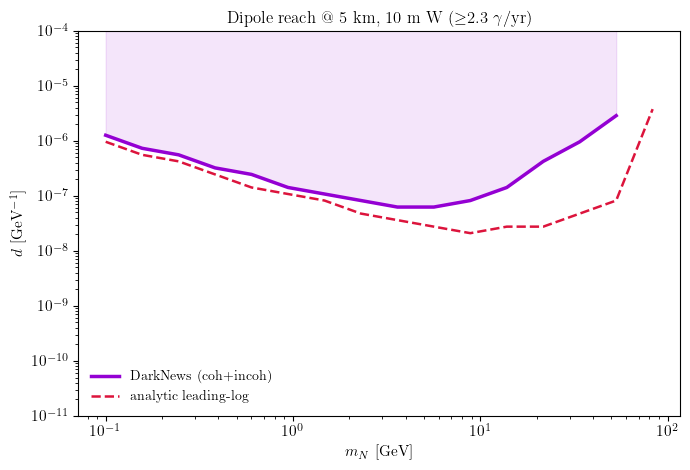

In [11]:
detector = hnl.ForwardDetector(distance_cm=DIST, radius_cm=DET_R, length_cm=1000.0, material=dt.W)
m_grid = np.geomspace(0.1, 500.0, 20)
d_grid = np.geomspace(1e-11, 1e-4, 60)

# DarkNews portals (slow step: one tabulation per mass, ~1-2 s each)
print("tabulating DarkNews cross sections per mass ...")
N_dn = np.zeros((m_grid.size, d_grid.size))
for i, m in enumerate(m_grid):
    portal = hnl.DarkNewsPortal(m, coupling_kind="dipole", target="W184", NEVAL=1000)
    for j, d in enumerate(d_grid):
        N_dn[i, j] = hnl.signal_events(E_nu, w_nu, portal, d, detector)
low_dn, _ = hnl.exclusion_band(m_grid, d_grid, N_dn, n_events=2.3)

# analytic estimate on the same grid, for comparison
N_an = hnl.sensitivity_grid(E_nu, w_nu, m_grid, d_grid, detector,
                            portal_factory=lambda m: hnl.DipolePortal(m))
low_an, _ = hnl.exclusion_band(m_grid, d_grid, N_an, n_events=2.3)

fig, ax = plt.subplots(figsize=(7, 4.8))
ax.plot(m_grid, low_dn, color="darkviolet", lw=2.5, label="DarkNews (coh+incoh)")
ax.plot(m_grid, low_an, color="crimson", lw=1.8, ls="--", label="analytic leading-log")
ax.fill_between(m_grid, low_dn, 1e-4, color="darkviolet", alpha=0.10)
ax.set_xscale("log"); ax.set_yscale("log"); ax.set_ylim(1e-11, 1e-4)
ax.set_xlabel(r"$m_N$ [GeV]"); ax.set_ylabel(r"$d$ [GeV$^{-1}$]")
ax.set_title(r"Dipole reach @ 5 km, 10 m W ($\geq$2.3 $\gamma$/yr)")
ax.legend(frameon=False); plt.tight_layout()

i = np.nanargmin(low_dn)
print(f"DarkNews best reach: d ~ {np.nanmin(low_dn):.2e} GeV^-1 at m_N = {m_grid[i]:.1f} GeV")
print(f"highest mass with any reach: {m_grid[np.isfinite(low_dn)].max():.1f} GeV")


## 4. Notes

- **High-mass turn-off is physical.** The left panel of §2 shows the coherent rate
  collapsing above $m_N\sim$ several GeV while the incoherent (nucleon-elastic) channel
  carries the rate to higher mass; the right panel shows the analytic leading-log
  coherent estimate ignoring this and overshooting by orders of magnitude at high mass.
  The reach (§3) reflects the difference: DarkNews cuts off where production truly dies.
- **Reach extends well above the $D$-meson region** — into the tens-of-GeV range — driven
  by the multi-TeV tail of the flux (heavier $N$ needs higher $E_\nu$).
- **Still first-pass on everything else:** single homogeneous block (lower reach edge
  only), analytic decay widths, zero background, and only the $\bar\nu_\mu$ beam. DIS
  upscattering (not included, per scope) would add rate at the highest masses/energies.
- DarkNews computes production at a reference coupling and everything is rescaled by
  coupling$^2$; tabulation is the only slow step (a few seconds per mass).